In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from typing import Tuple, Any, Dict
import math
from src.utils import (
    load_config,
    load_data,
    split_input_output,
    split_train_test,
    serialize_data,
    deserialize_data
)

In [2]:
config = load_config()

In [3]:
config

{'directories': {'raw': 'data/raw',
  'interim': 'data/interim',
  'processed': 'data/processed'},
 'files': {'dataset_name': 'credit_risk_dataset.csv',
  'interim': {'X_train': 'X_train.pkl',
   'y_train': 'y_train.pkl',
   'X_valid': 'X_valid.pkl',
   'y_valid': 'y_valid.pkl',
   'X_test': 'X_test.pkl',
   'y_test': 'y_test.pkl'}},
 'path_raw_dir': '/home/amadeo/Pacmann/MLProcess/Mentoring/AMADEO_MLPROCESS/data/raw',
 'path_interim_dir': '/home/amadeo/Pacmann/MLProcess/Mentoring/AMADEO_MLPROCESS/data/interim',
 'path_processed_dir': '/home/amadeo/Pacmann/MLProcess/Mentoring/AMADEO_MLPROCESS/data/processed',
 'path_raw_data': '/home/amadeo/Pacmann/MLProcess/Mentoring/AMADEO_MLPROCESS/data/raw/credit_risk_dataset.csv',
 'path_X_train': '/home/amadeo/Pacmann/MLProcess/Mentoring/AMADEO_MLPROCESS/data/interim/X_train.pkl',
 'path_y_train': '/home/amadeo/Pacmann/MLProcess/Mentoring/AMADEO_MLPROCESS/data/interim/y_train.pkl',
 'path_X_valid': '/home/amadeo/Pacmann/MLProcess/Mentoring/AMADEO

In [7]:
X_TRAIN_PATH = config["path_X_train"]
Y_TRAIN_PATH = config["path_y_train"]

In [8]:
X_train = deserialize_data(X_TRAIN_PATH)
y_train = deserialize_data(Y_TRAIN_PATH)


In [6]:
X_train.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
15884,25,241875,MORTGAGE,4.0,EDUCATION,A,16000,7.05,0.07,N,4
15138,21,18000,RENT,5.0,PERSONAL,B,1500,12.18,0.08,N,4
7474,25,53000,MORTGAGE,10.0,MEDICAL,B,16000,12.53,0.30,N,2
18212,28,16800,OWN,NaN,MEDICAL,C,5000,13.98,0.30,N,8
6493,25,50000,MORTGAGE,2.0,VENTURE,A,10000,7.90,0.20,N,2


In [9]:
y_train.head()

15884    0
15138    1
7474     0
18212    1
6493     0
Name: loan_status, dtype: int64

In [10]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 26064 entries, 15884 to 17068
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  26064 non-null  int64  
 1   person_income               26064 non-null  int64  
 2   person_home_ownership       26064 non-null  str    
 3   person_emp_length           25326 non-null  float64
 4   loan_intent                 26064 non-null  str    
 5   loan_grade                  26064 non-null  str    
 6   loan_amnt                   26064 non-null  int64  
 7   loan_int_rate               23563 non-null  float64
 8   loan_percent_income         26064 non-null  float64
 9   cb_person_default_on_file   26064 non-null  str    
 10  cb_person_cred_hist_length  26064 non-null  int64  
dtypes: float64(3), int64(4), str(4)
memory usage: 2.4 MB


In [11]:
num_col = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length"
]

cat_col = [
    "person_home_ownership",
    "loan_intent",
    "loan_grade",
    "cb_person_default_on_file"
]

data_num = X_train[num_col]
data_cat = X_train[cat_col]

In [12]:
data_num.info()

<class 'pandas.DataFrame'>
Index: 26064 entries, 15884 to 17068
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  26064 non-null  int64  
 1   person_income               26064 non-null  int64  
 2   person_emp_length           25326 non-null  float64
 3   loan_amnt                   26064 non-null  int64  
 4   loan_int_rate               23563 non-null  float64
 5   loan_percent_income         26064 non-null  float64
 6   cb_person_cred_hist_length  26064 non-null  int64  
dtypes: float64(3), int64(4)
memory usage: 1.6 MB


In [13]:
data_cat.info()

<class 'pandas.DataFrame'>
Index: 26064 entries, 15884 to 17068
Data columns (total 4 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   person_home_ownership      26064 non-null  str  
 1   loan_intent                26064 non-null  str  
 2   loan_grade                 26064 non-null  str  
 3   cb_person_default_on_file  26064 non-null  str  
dtypes: str(4)
memory usage: 1018.1 KB


In [15]:
data_duplikat = X_train[X_train.index.duplicated(keep=False)]
data_duplikat

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length


In [16]:
data_sorted = X_train.sort_values(by="person_income", ascending=False)
data_sorted.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
32297,144,6000000,MORTGAGE,12.0,PERSONAL,C,5000,12.73,0.00,N,25
30049,42,2039784,RENT,0.0,VENTURE,C,8450,12.29,0.00,Y,15
32497,63,1782000,RENT,13.0,EDUCATION,C,12025,14.27,0.01,N,30
31924,44,1440000,MORTGAGE,7.0,DEBTCONSOLIDATION,A,6400,7.40,0.00,N,15
17833,32,1200000,MORTGAGE,1.0,VENTURE,A,12000,7.51,0.01,N,8


In [17]:
X_train.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              738
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 2501
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

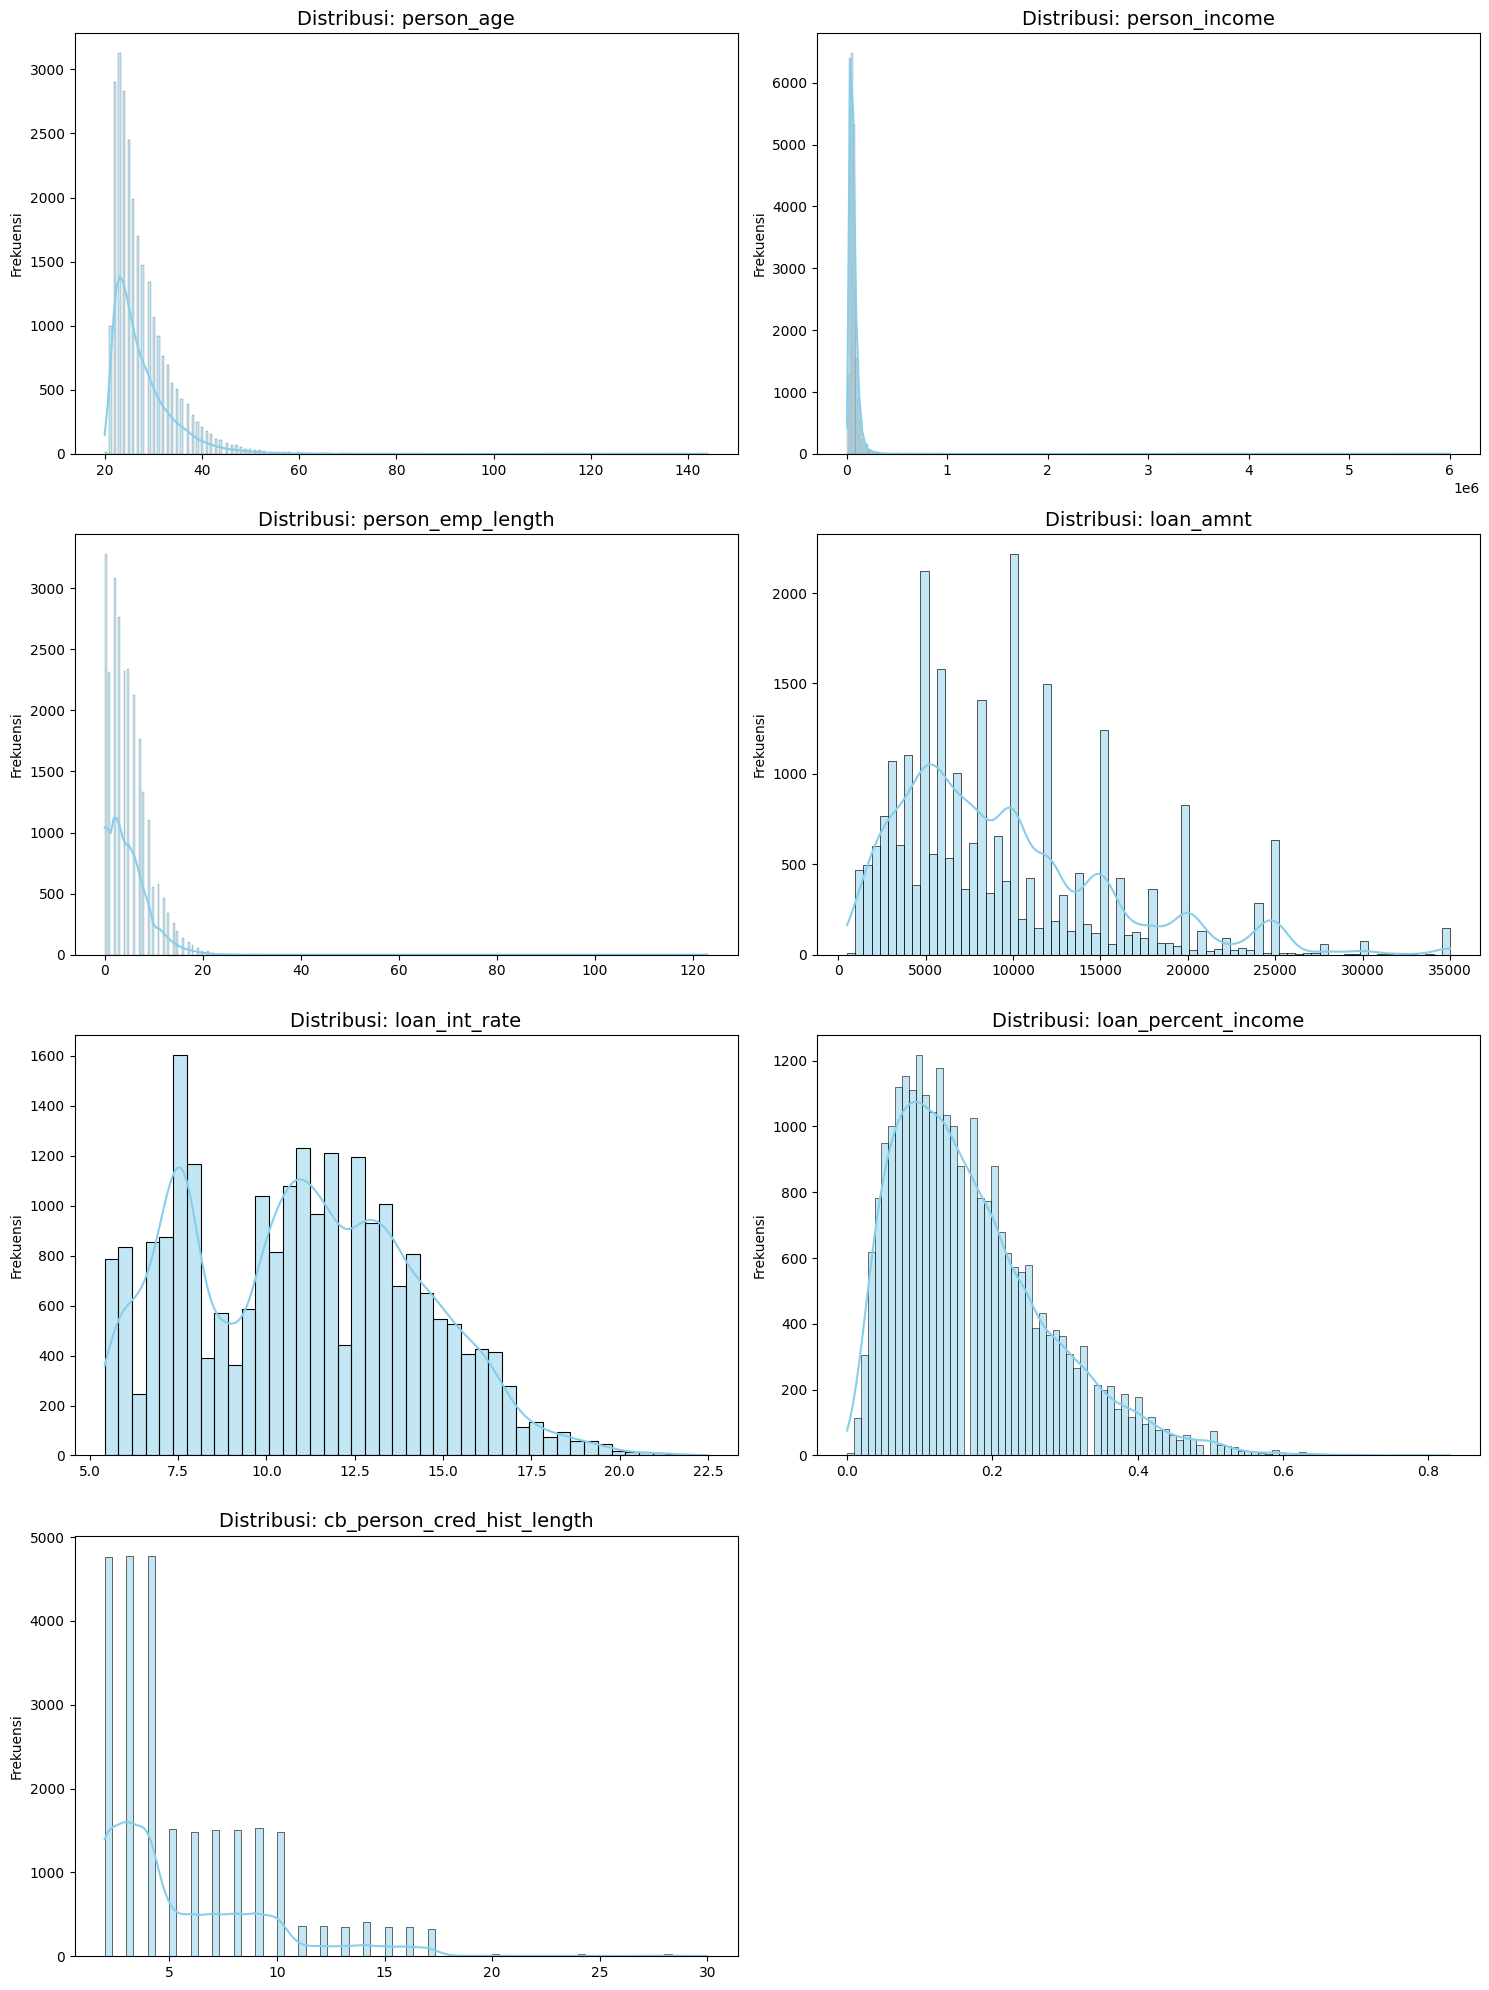

In [26]:
num_features = num_col

fig, axes = plt.subplots(4, 2, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.histplot(data=X_train, x=col, kde=True, ax=axes[i], color="skyblue")
    axes[i].set_title(f"Distribusi: {col}", fontsize=14)
    axes[i].set_xlabel("") 
    axes[i].set_ylabel("Frekuensi")

fig.delaxes(axes[7])
plt.tight_layout()
plt.show()


In [39]:
X_bersihan = X_train.drop(32297)
y_bersihan = y_train.drop(32297)

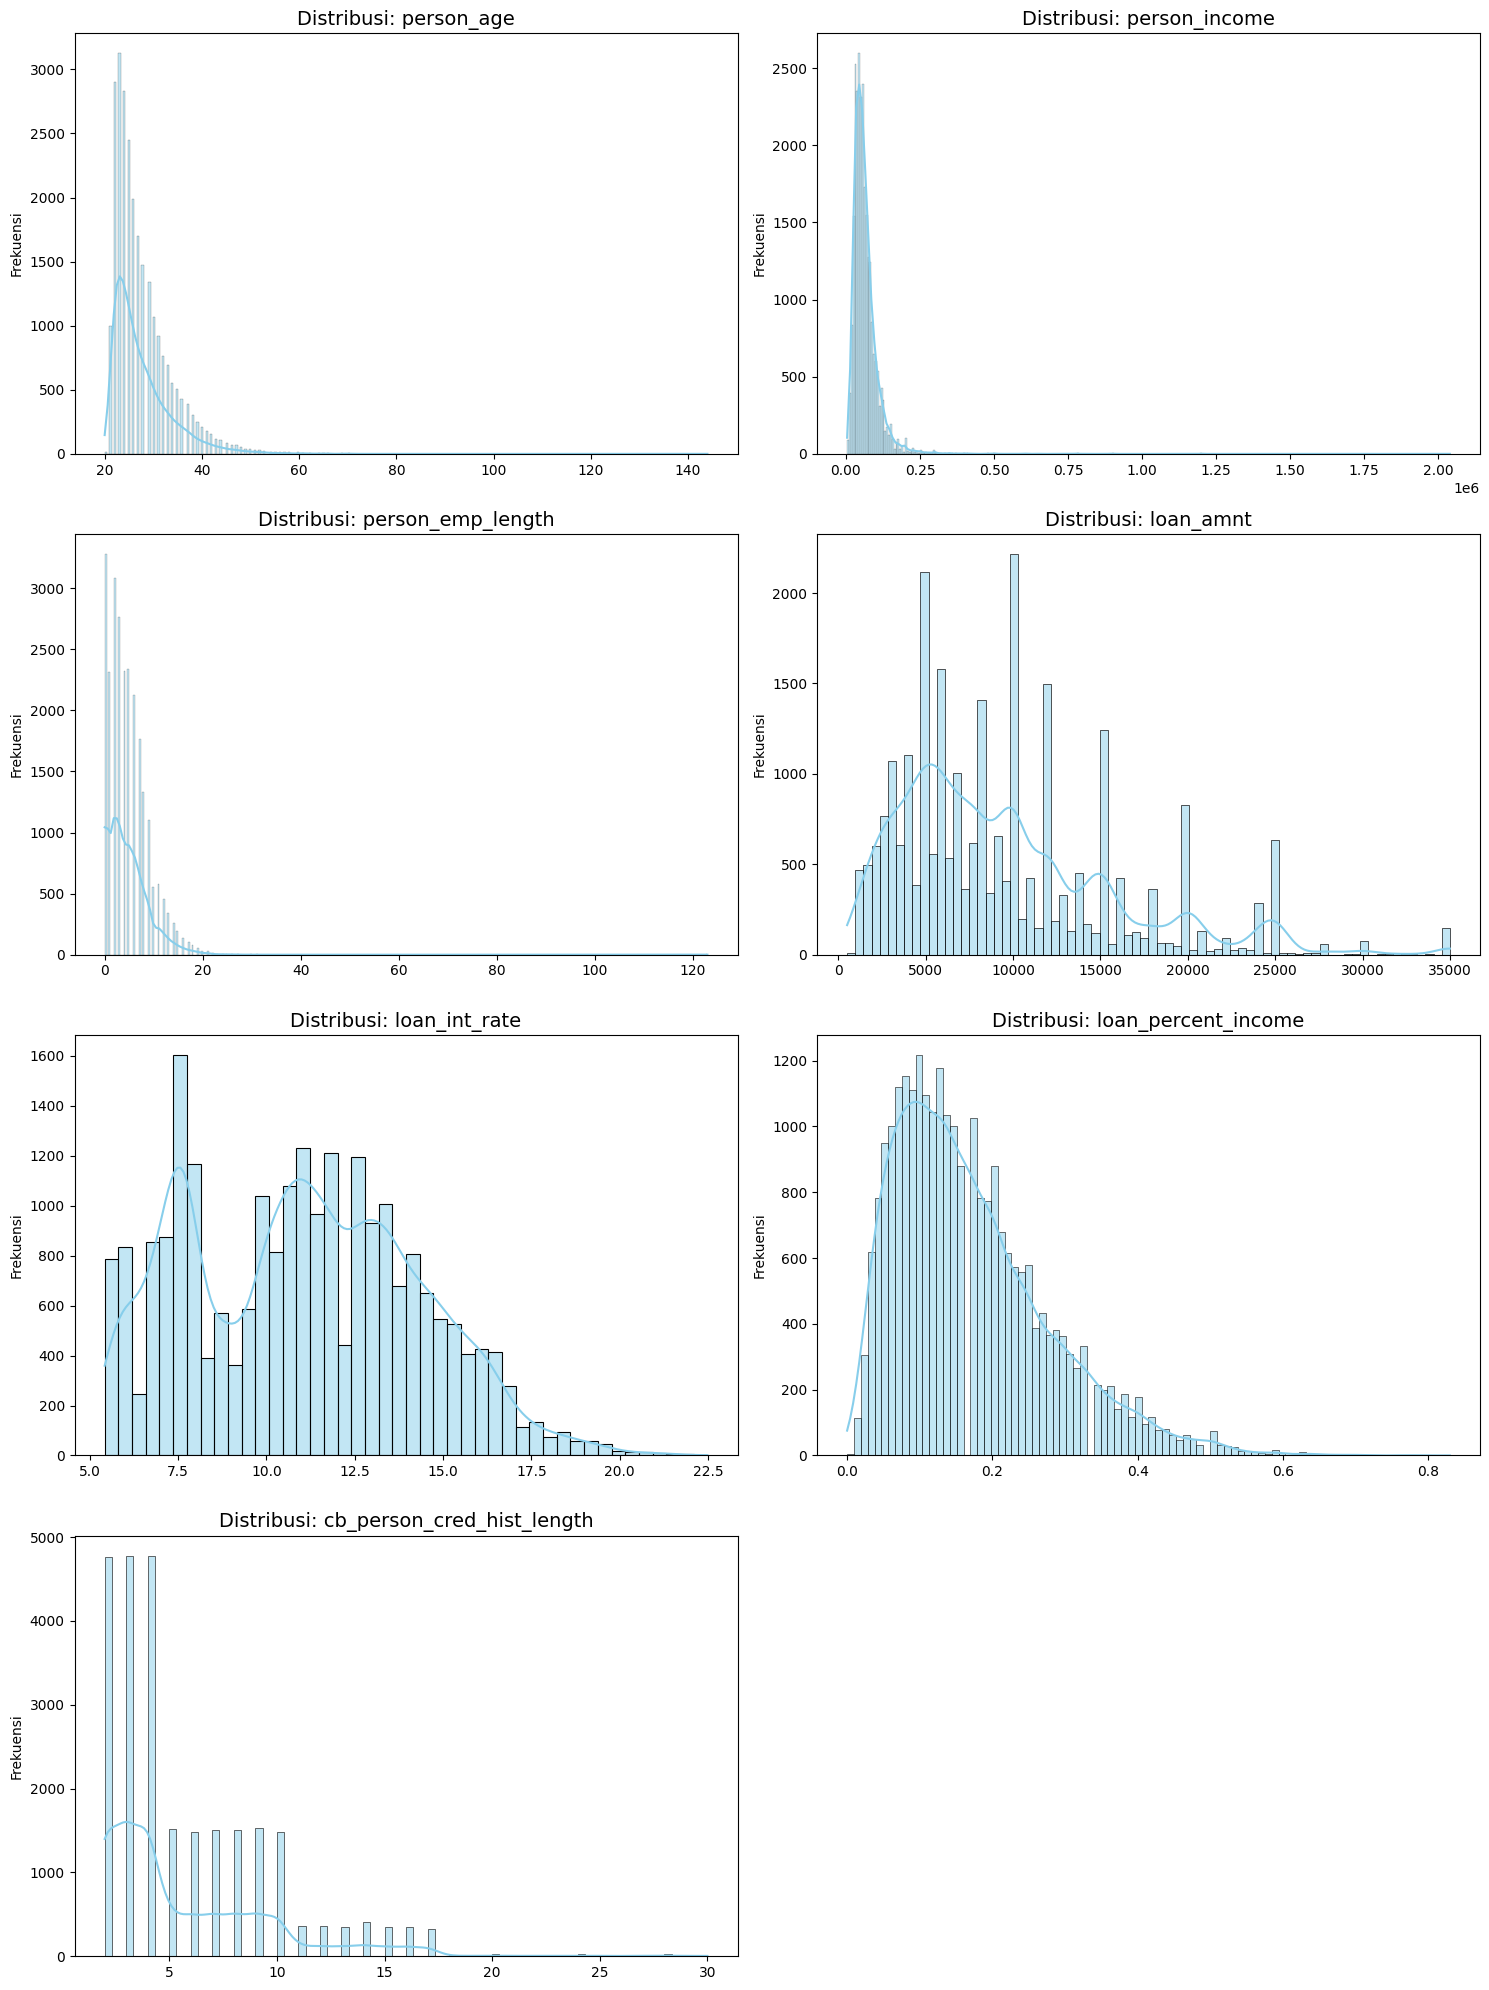

In [28]:
num_features = num_col

fig, axes = plt.subplots(4, 2, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.histplot(data=X_bersihan, x=col, kde=True, ax=axes[i], color="skyblue")
    axes[i].set_title(f"Distribusi: {col}", fontsize=14)
    axes[i].set_xlabel("") 
    axes[i].set_ylabel("Frekuensi")

fig.delaxes(axes[7])
plt.tight_layout()
plt.show()


In [29]:
X_gaji = X_train[X_train["person_income"] <= 1000000]

In [30]:
X_gaji.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
15884,25,241875,MORTGAGE,4.0,EDUCATION,A,16000,7.05,0.07,N,4
15138,21,18000,RENT,5.0,PERSONAL,B,1500,12.18,0.08,N,4
7474,25,53000,MORTGAGE,10.0,MEDICAL,B,16000,12.53,0.30,N,2
18212,28,16800,OWN,NaN,MEDICAL,C,5000,13.98,0.30,N,8
6493,25,50000,MORTGAGE,2.0,VENTURE,A,10000,7.90,0.20,N,2


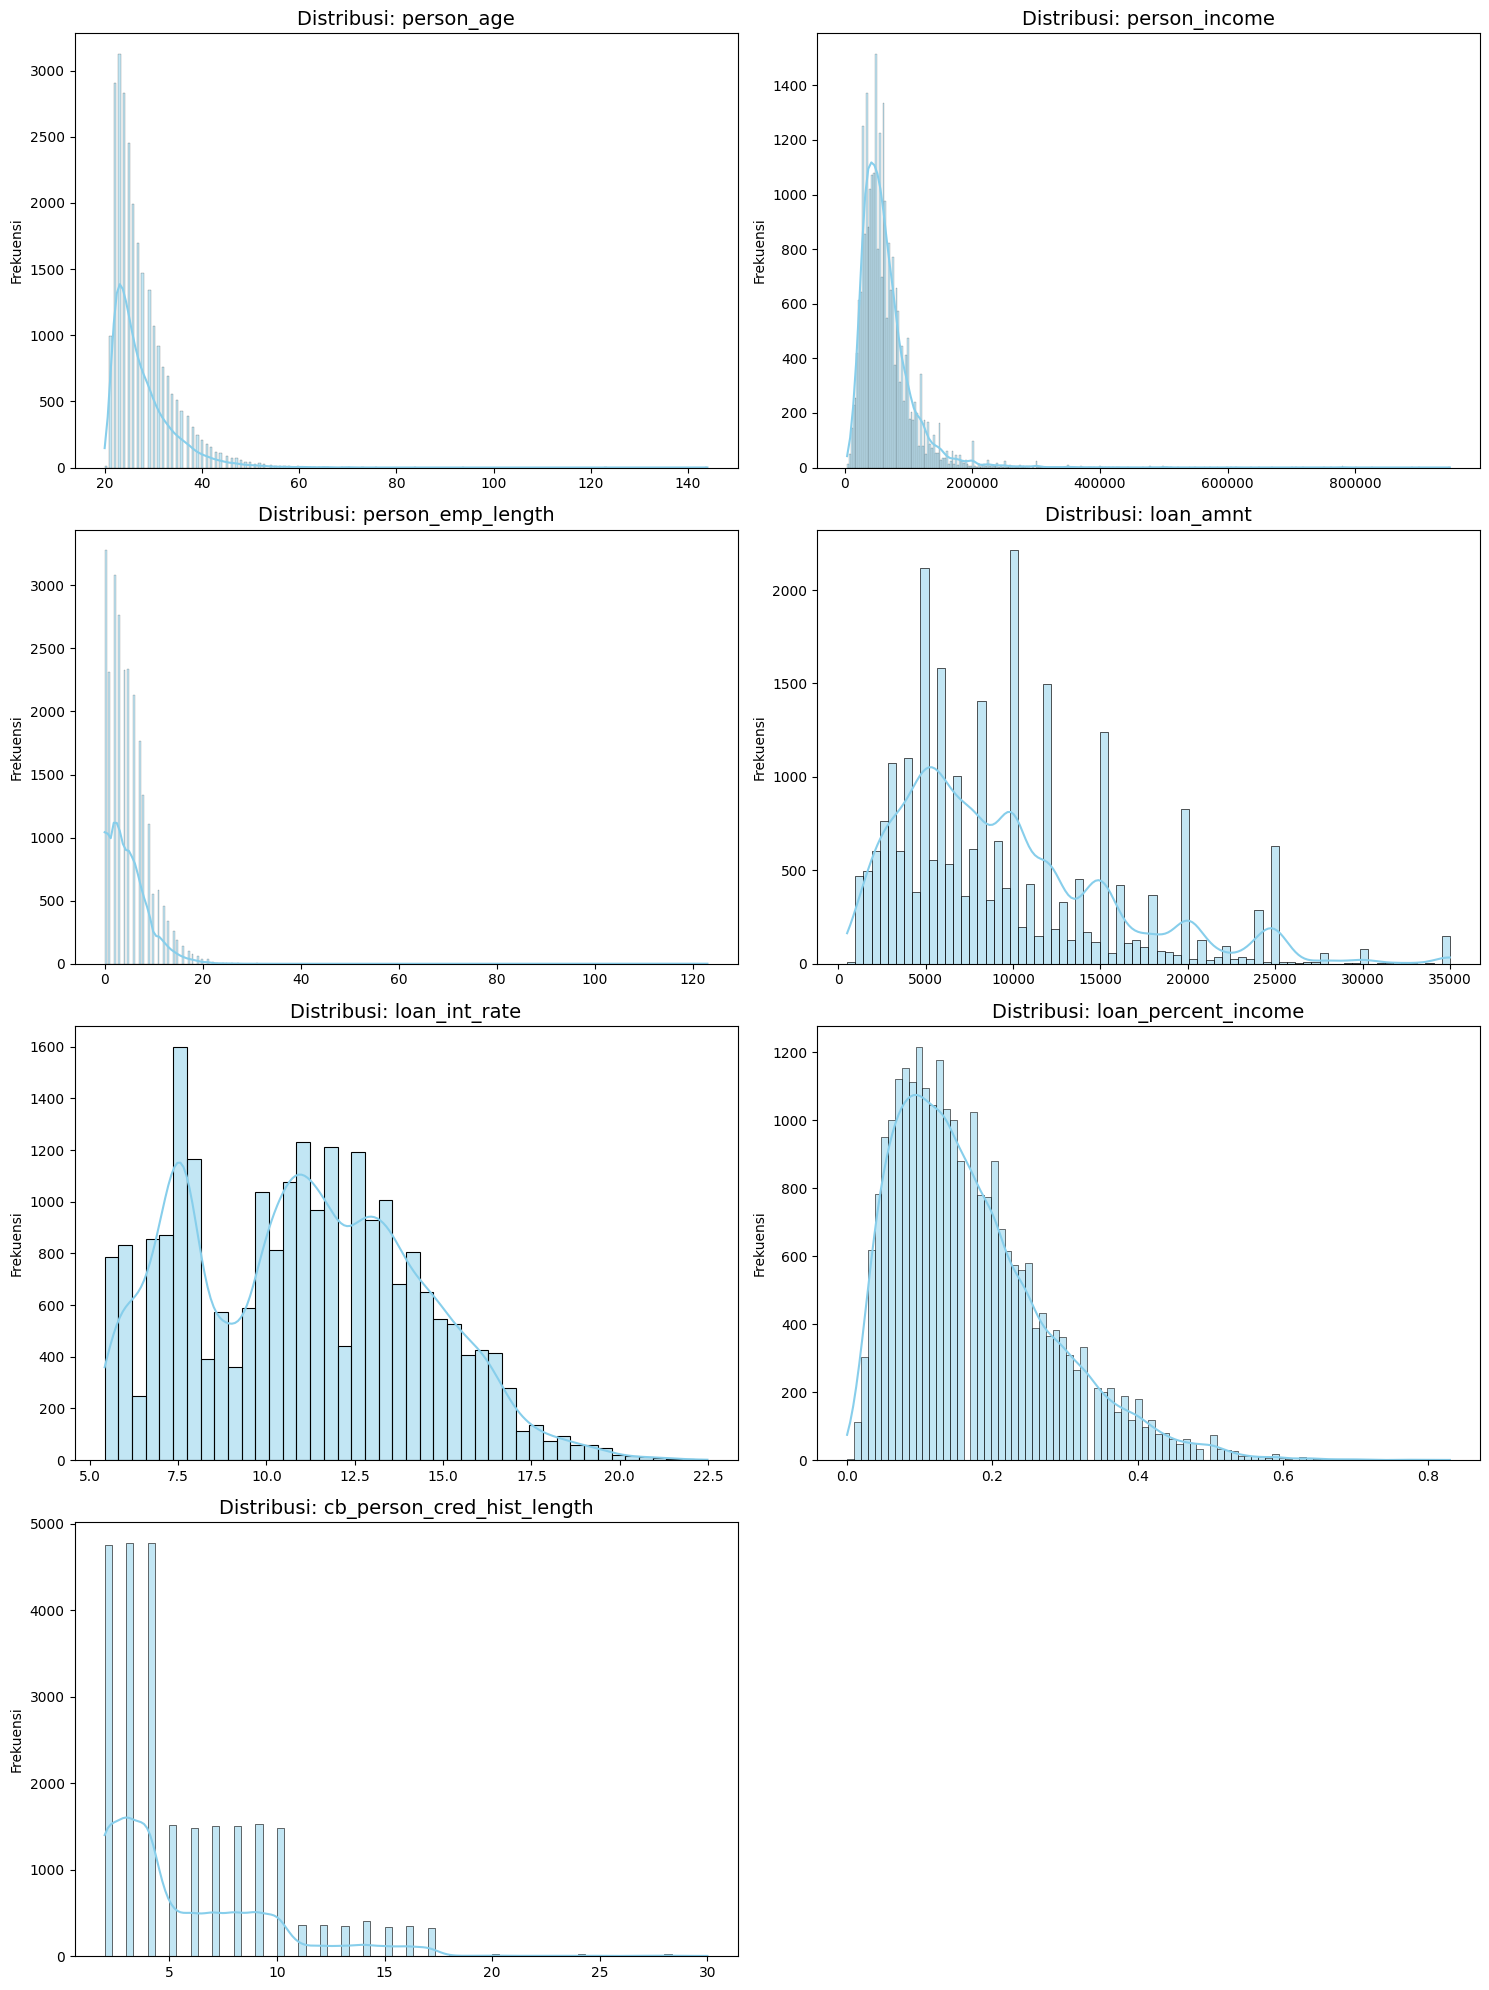

In [32]:
num_features = num_col

fig, axes = plt.subplots(4, 2, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.histplot(data=X_gaji, x=col, kde=True, ax=axes[i], color="skyblue")
    axes[i].set_title(f"Distribusi: {col}", fontsize=14)
    axes[i].set_xlabel("") 
    axes[i].set_ylabel("Frekuensi")

fig.delaxes(axes[7])
plt.tight_layout()
plt.show()


In [40]:
y_df = pd.DataFrame(y_bersihan)
y_df.head()

,loan_status
15884,0
15138,1
7474,0
18212,1
6493,0


<Axes: xlabel='loan_status', ylabel='count'>

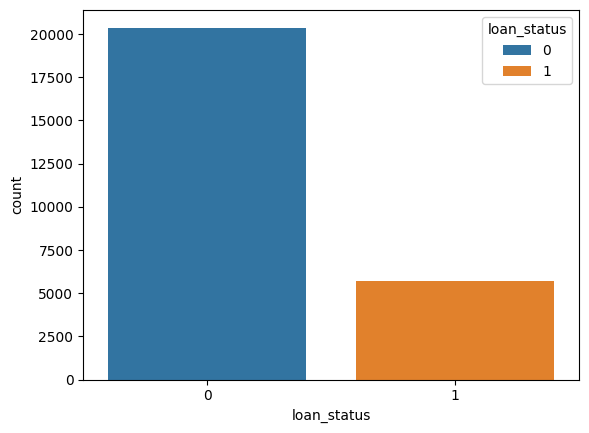

In [41]:
sns.countplot(data=y_df, x="loan_status", hue="loan_status")